# Exercises: Modularisation

Use this notebook for the practical tasks.

Before starting, ensure `plot_example.py` is open side-by-side with this notebook.

## Setup

### Important when editing modules

If you change `plot_example.py` while this notebook is open, you must refresh what the notebook sees.

`importlib` is a standard Python library module for working with imports programmatically.

`importlib.reload(module_name)` tells Python to re-read that module file from disk and replace the in-memory version.

You can either restart and run all cells, or reload the module in-place:

```python
import importlib
import plot_example
importlib.reload(plot_example)
```

Use reload whenever you edit functions in `plot_example.py` and want those edits to be used immediately in this notebook session.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

time = np.arange(0, 10, 0.1)
y = np.linspace(0, 5, len(time))**2

---

## Exercise 1

**Learning goal:** implement a missing function in a module and call it from a notebook.

In `plot_example.py`, find the `plot_uncert()` function stub (currently with `pass`).

Use this code inside `plot_uncert()`:

```python
# Define upper and lower bounds of shading using the error term
y_low = y - yerr
y_high = y + yerr

# Plot the line and the shading around it
ax.plot(x, y)
ax.fill_between(x, y1=y_low, y2=y_high, alpha=0.3, label=label)

ax.legend()
```

**Steps**
1) Update `plot_example.py` with this implementation.

2) Save the module, then import and run the test plot below.

3) If your edits do not appear, run `importlib.reload(plot_example)` before testing.

**Success check:** your figure should show a line with a shaded uncertainty region around it.

In [ ]:
# Add your import here
# from plot_example import plot_uncert

In [ ]:
# Uncomment after plot_uncert() is implemented
# fig, ax = plt.subplots()
# y_err = y * 0.1
# plot_uncert(time, y, y_err, ax, label='x')

---

## Exercise 2

**Learning goal:** identify reusable vs dataset-specific code and wrap reusable parts in a function.

**Steps**
1) Recreate the matplotlib stackplot demo in the cell below:
https://matplotlib.org/stable/gallery/lines_bars_and_markers/stackplot_demo.html

In [ ]:
# Copy stackplot demo code here

Consider which parts are generic and which are specific to one dataset.

2) In `plot_example.py`, use the provided `plot_population_stacked()` stub (or create your own more generic function).
3) Import your function and test it in this notebook.

**Success check:** your function plots a stackplot from inputs, rather than hard-coded values.

In [ ]:
# Edit plot_population_stacked() in plot_example.py
# Then import your function here

In [ ]:
# Add code to test your stackplot function here

**Questions**
- How could this function be improved?
- How could it be made generic enough for any stackplot, not just year vs population?
- Could the input structure be improved beyond a dictionary of lists?

---

## Exercise 3

**Learning goal:** understand notebook module caching and verify that reload applies code edits.

**Steps**
1) In `plot_example.py`, modify `time_scatter()` so it accepts an optional `marker` argument (default `'+'`) and uses that marker in `ax.scatter(...)`.
2) Save `plot_example.py`, then reload the module in this notebook and test two different markers.
3) Briefly note what happened before and after reloading.

**Success check:** your plot displays different marker styles, and your notes explain why reload was needed.

In [ ]:
# Reload and test your updated function here
# import importlib
# import plot_example
# importlib.reload(plot_example)
#
# fig, ax = plt.subplots()
# plot_example.time_scatter(time, y, ax=ax, label='plus', marker='+')
# plot_example.time_scatter(time, y*0.8, ax=ax, label='circle', marker='o')

Write 2-3 sentences: Why is reloading needed in notebooks when a module file changes?

---

## Exercise 4

**Learning goal:** improve function robustness with validation and configurable parameters.

**Steps**
1) Update `plot_population_stacked()` so it checks that every population series has the same length as `year`.
2) If a mismatch is found, raise a `ValueError` with a clear message.
3) Add optional inputs `legend_loc='upper left'` and `alpha=0.85`, then use them in the plot.
4) Demonstrate one valid call and one invalid call (inside `try/except`) below.

**Success check:** the valid example plots correctly, and the invalid example raises your custom error message.

In [ ]:
# Demonstrate valid and invalid calls to your improved stackplot function
# (use try/except for the invalid case)

## Exercise 5

Now you can create your own modularised plotting function. The problem you want to solve is to take input data in `x` and `y` sequences and construct a funciton that plots the data together with an arbitrary polynomial fit of specified degree. You can use `numpy.polyfit()` to compute the polynomial coefficients and `numpy.polyval()` to create a polynomial function that can be evaluated at any `x` value.

**Steps**

1. Write the function in the notebook first, and experiment a bit
1. Move the function to `plot_example.py` and test it in this notebook.
1. Make sure that you have added suitable error handling to your function, and test that it works by calling the function with wrong inputs.
1. Make sure that you have added a docstring to your function, and test that it is informative and clear by calling `help(your_function_name)`.\

**Success check** Test the function with some synthetic data. 

Then test it again with a real dataset, by taking the UK time series from  the *Energy per person dataset* from Our World in Data here below.


<Axes: xlabel='year'>

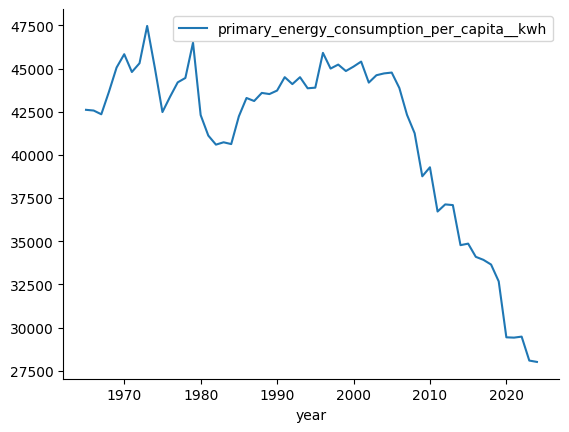

In [9]:
import pandas as pd
# Fetch the data.
df = pd.read_csv("https://ourworldindata.org/grapher/per-capita-energy-use.csv?v=1&csvType=full&useColumnShortNames=true", 
                 )

# UK series
df_uk = df[df['entity'] == 'United Kingdom']
df_uk.plot(x='year', y='primary_energy_consumption_per_capita__kwh')

### Solution: Plot with polynomial fit

Here's the complete function with docstring, validation, and error handling:

In [12]:
import numpy as np
import matplotlib.pyplot as plt
def plot_with_polynomial_fit(x, y, ax, degree=2, label=None):
    '''
    Plot data points with an overlaid polynomial fit line.
    
    Args:
        x (array-like): 
            X-values (must be numeric and iterable)
        y (array-like): 
            Y-values (must be numeric, same length as x)
        ax (matplotlib.axes.Axes): 
            Axes object to use for plotting
        degree (int, optional): 
            Degree of polynomial fit (default = 2, i.e. quadratic)
        label (str, optional): 
            Label for the data points in the legend (default = None)
    
    Returns:
        None
        Modifies `ax` input to add scatter plot and polynomial fit line.
    
    Raises:
        ValueError: 
            If x and y have different lengths
        TypeError: 
            If x or y cannot be converted to numeric arrays
    
    Example:
        >>> import matplotlib.pyplot as plt
        >>> import numpy as np
        >>> x_data = np.linspace(0, 10, 50)
        >>> y_data = x_data**2 + np.random.normal(0, 5, 50)
        >>> fig, ax = plt.subplots()
        >>> plot_with_polynomial_fit(x_data, y_data, ax, degree=2, label='data')
    '''
    try:
        # Convert to numpy arrays
        x = np.asarray(x, dtype=float)
        y = np.asarray(y, dtype=float)
        
        # Validate lengths match
        if len(x) != len(y):
            raise ValueError(f"x and y must have the same length. Got {len(x)} and {len(y)}")
        
        # Validate we have enough points for the fit
        if len(x) < degree + 1:
            raise ValueError(f"Need at least {degree + 1} points for degree {degree} polynomial fit. Got {len(x)}")
        
        # Compute polynomial fit
        coeffs = np.polyfit(x, y, degree)
        poly_fn = np.poly1d(coeffs)
        
        # Create smooth line for display
        x_smooth = np.linspace(x.min(), x.max(), 200)
        y_smooth = poly_fn(x_smooth)
        
        # Plot original data and fit
        ax.scatter(x, y, label=label, marker='o', alpha=0.6)
        ax.plot(x_smooth, y_smooth, 'r-', linewidth=2, label=f'Polynomial fit (degree {degree})')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.legend()
        
    except ValueError as e:
        print(f"Validation error: {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

### Test 1: Synthetic data (with error handling)

Text(0.5, 1.0, 'Valid test: Polynomial fit on synthetic data')

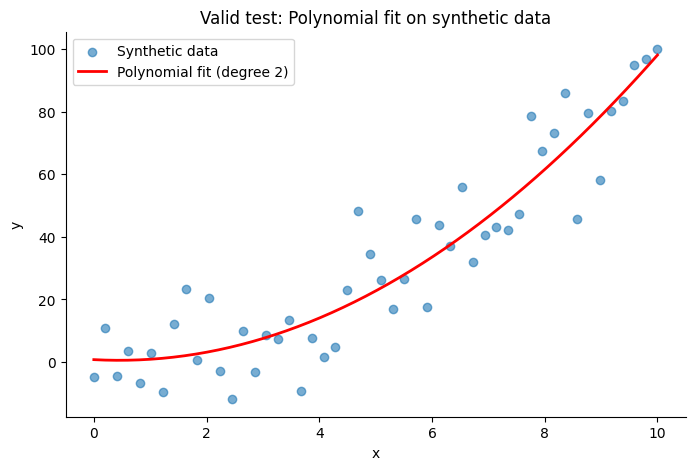

In [13]:
# Valid case: synthetic quadratic data with noise
x_synthetic = np.linspace(0, 10, 50)
y_synthetic = x_synthetic**2 + np.random.normal(0, 10, 50)

fig, ax = plt.subplots(figsize=(8, 5))
plot_with_polynomial_fit(x_synthetic, y_synthetic, ax, degree=2, label='Synthetic data')
plt.title("Valid test: Polynomial fit on synthetic data")

### Test 2: Error handling

Error case 1: Mismatched x and y lengths
Validation error: x and y must have the same length. Got 3 and 2
Error case 2: Not enough data points for fit
Validation error: Need at least 4 points for degree 3 polynomial fit. Got 2
Error case 3: Non-numeric data
Validation error: could not convert string to float: 'a'


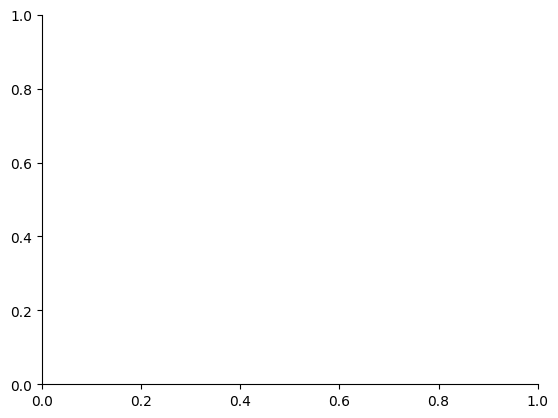

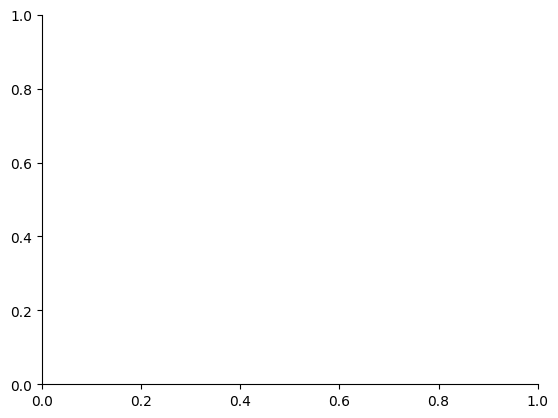

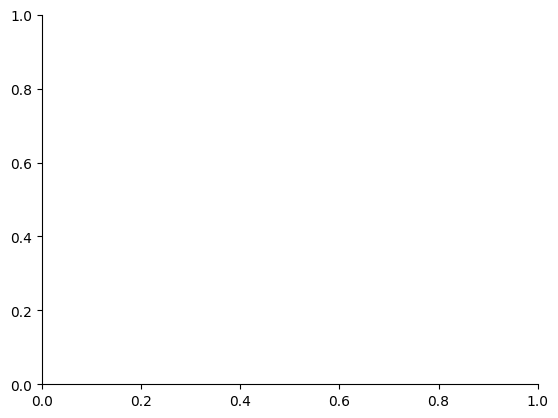

In [14]:
# Error case 1: Mismatched lengths
print("Error case 1: Mismatched x and y lengths")
try:
    fig, ax = plt.subplots()
    plot_with_polynomial_fit([1, 2, 3], [1, 2], ax, degree=2)
except Exception as e:
    print(f"Caught exception: {e}\n")

# Error case 2: Not enough points for polynomial degree
print("Error case 2: Not enough data points for fit")
try:
    fig, ax = plt.subplots()
    plot_with_polynomial_fit([1, 2], [1, 2], ax, degree=3)
except Exception as e:
    print(f"Caught exception: {e}\n")

# Error case 3: Non-numeric data
print("Error case 3: Non-numeric data")
try:
    fig, ax = plt.subplots()
    plot_with_polynomial_fit(['a', 'b', 'c'], [1, 2, 3], ax, degree=1)
except Exception as e:
    print(f"Caught exception: {e}\n")

### Test 3: Real-world UK energy data

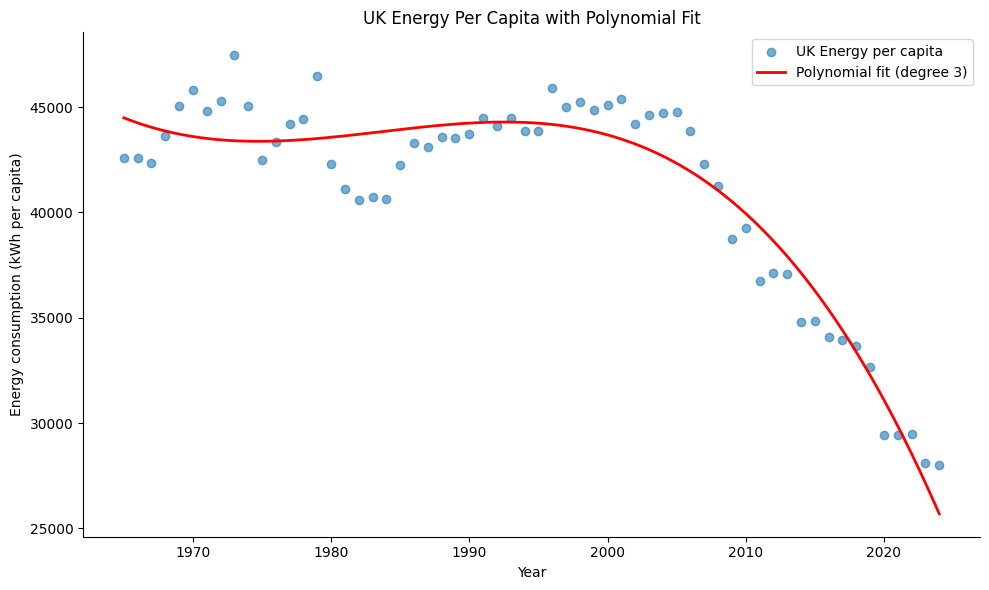

In [15]:
# Extract UK data (remove any NaN values)
uk_years = df_uk['year'].dropna().values
uk_energy = df_uk['primary_energy_consumption_per_capita__kwh'].dropna().values

# Align the data (remove rows where either is NaN)
valid_idx = ~(np.isnan(uk_years) | np.isnan(uk_energy))
uk_years = uk_years[valid_idx]
uk_energy = uk_energy[valid_idx]

# Plot with our function
fig, ax = plt.subplots(figsize=(10, 6))
plot_with_polynomial_fit(uk_years, uk_energy, ax, degree=3, label='UK Energy per capita')
ax.set_xlabel('Year')
ax.set_ylabel('Energy consumption (kWh per capita)')
ax.set_title('UK Energy Per Capita with Polynomial Fit')
plt.tight_layout()